# RandomForest Cirrhosis Optimized
Target: Cirrhosis_Status

Saving liver_cirrhosis.csv to liver_cirrhosis (1).csv
Dataset shape: (25000, 19)
   N_Days Status     Drug    Age Sex Ascites Hepatomegaly Spiders Edema  \
0    2221      C  Placebo  18499   F       N            Y       N     N   
1    1230      C  Placebo  19724   M       Y            N       Y     N   
2    4184      C  Placebo  11839   F       N            N       N     N   
3    2090      D  Placebo  16467   F       N            N       N     N   
4    2105      D  Placebo  21699   F       N            Y       N     N   

   Bilirubin  Cholesterol  Albumin  Copper  Alk_Phos    SGOT  Tryglicerides  \
0        0.5        149.0     4.04   227.0     598.0   52.70           57.0   
1        0.5        219.0     3.93    22.0     663.0   45.00           75.0   
2        0.5        320.0     3.54    51.0    1243.0  122.45           80.0   
3        0.7        255.0     3.74    23.0    1024.0   77.50           58.0   
4        1.9        486.0     3.54    74.0    1052.0  108.50          109

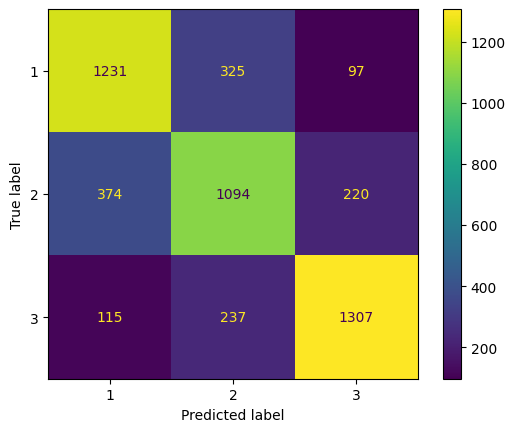


TOP FEATURES
                Feature  Importance
10     num__Prothrombin    0.180106
0           num__N_Days    0.111645
9        num__Platelets    0.093672
20  cat__Hepatomegaly_N    0.088248
4          num__Albumin    0.078779
21  cat__Hepatomegaly_Y    0.072297
2        num__Bilirubin    0.046196
6         num__Alk_Phos    0.043976
24         cat__Edema_N    0.039398
1              num__Age    0.034152
7             num__SGOT    0.032794
3      num__Cholesterol    0.025690
5           num__Copper    0.024414
13        cat__Status_D    0.023258
8    num__Tryglicerides    0.022539


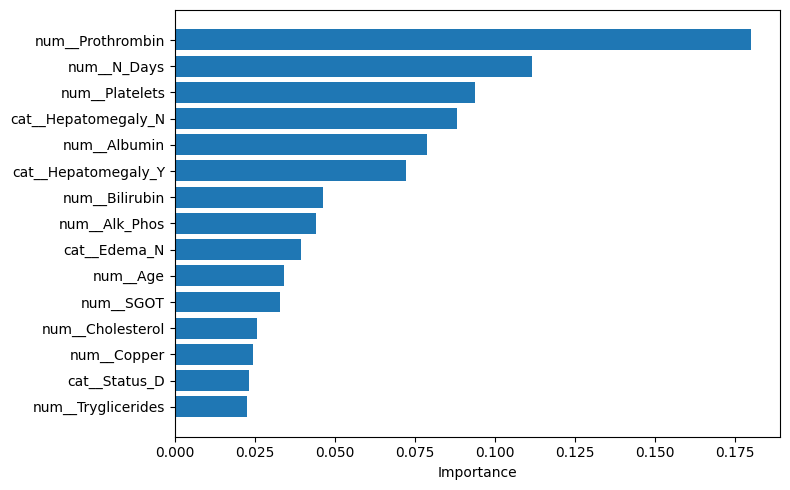


Saved successfully!


In [2]:
# ======================================
# Efficient Random Forest Liver Cirrhosis
# ======================================

!pip install -q scikit-learn


import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import joblib


from google.colab import files

from sklearn.model_selection import train_test_split

from sklearn.preprocessing import LabelEncoder

from sklearn.impute import SimpleImputer

from sklearn.compose import ColumnTransformer

from sklearn.pipeline import Pipeline

from sklearn.preprocessing import OneHotEncoder

from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)



# ======================
# Load Dataset
# ======================

uploaded = files.upload()

filename = list(uploaded.keys())[0]

df = pd.read_csv(filename)


df.columns = df.columns.str.strip()


print("Dataset shape:",df.shape)

print(df.head())



# ======================
# Target
# ======================

target="Stage"


X=df.drop(columns=[target])

y=df[target]



# Encode target

label_encoder=LabelEncoder()

y=label_encoder.fit_transform(y)


print("\nClasses:")
print(label_encoder.classes_)



# ======================
# Detect columns
# ======================

num_cols=X.select_dtypes(
    include=["int64","float64"]
).columns


cat_cols=X.select_dtypes(
    include=["object"]
).columns



print("\nNumeric:",len(num_cols))

print("Categorical:",len(cat_cols))



# ======================
# Preprocessing
# ======================


preprocessor=ColumnTransformer([

    (
        "num",
        SimpleImputer(strategy="median"),
        num_cols
    ),


    (
        "cat",
        Pipeline([

            ("imputer",
             SimpleImputer(strategy="most_frequent")),


            ("encoder",
             OneHotEncoder(
                 handle_unknown="ignore"
             ))

        ]),
        cat_cols
    )

])



# ======================
# Random Forest
# ======================


rf=RandomForestClassifier(

    n_estimators=300,

    max_depth=5,

    min_samples_split=5,

    min_samples_leaf=3,

    max_features="sqrt",

    class_weight="balanced",

    random_state=42,

    n_jobs=-1

)



model=Pipeline([

    ("prep",preprocessor),

    ("rf",rf)

])



# ======================
# Split
# ======================


X_train,X_test,y_train,y_test=train_test_split(

    X,
    y,

    test_size=0.2,

    stratify=y,

    random_state=42

)



# ======================
# Train
# ======================


model.fit(
    X_train,
    y_train
)



# ======================
# Evaluation
# ======================


pred=model.predict(X_test)



print("\nAccuracy:",
      accuracy_score(y_test,pred))


print("Precision:",
      precision_score(
          y_test,
          pred,
          average="weighted"
      ))


print("Recall:",
      recall_score(
          y_test,
          pred,
          average="weighted"
      ))


print("F1:",
      f1_score(
          y_test,
          pred,
          average="weighted"
      ))



print("\nReport:")

print(
classification_report(
    y_test,
    pred,
    target_names=label_encoder.classes_.astype(str)
)
)


# ======================
# Confusion Matrix
# ======================


cm=confusion_matrix(
    y_test,
    pred
)


ConfusionMatrixDisplay(

    confusion_matrix=cm,

    display_labels=label_encoder.classes_.astype(str)

).plot()

plt.show()



# ======================
# Feature importance
# ======================


rf_model=model.named_steps["rf"]


feature_names=model.named_steps[
    "prep"
].get_feature_names_out()



importance=pd.DataFrame({

    "Feature":feature_names,

    "Importance":
    rf_model.feature_importances_

})


importance=importance.sort_values(
    "Importance",
    ascending=False
)



print("\nTOP FEATURES")

print(
importance.head(15)
)



plt.figure(figsize=(8,5))


plt.barh(

    importance.head(15)["Feature"][::-1],

    importance.head(15)["Importance"][::-1]

)


plt.xlabel("Importance")

plt.tight_layout()

plt.show()



# ======================
# Save
# ======================


joblib.dump(
    model,
    "RandomForest_Cirrhosis.pkl"
)


joblib.dump(
    label_encoder,
    "Stage_LabelEncoder.pkl"
)


print("\nSaved successfully!")

In [2]:
import pandas as pd
from google.colab import files

uploaded = files.upload()
filename = list(uploaded.keys())[0]

df = pd.read_csv(filename)

print(df.columns.tolist())

Saving liver_cirrhosis.csv to liver_cirrhosis (3).csv
['N_Days', 'Status', 'Drug', 'Age', 'Sex', 'Ascites', 'Hepatomegaly', 'Spiders', 'Edema', 'Bilirubin', 'Cholesterol', 'Albumin', 'Copper', 'Alk_Phos', 'SGOT', 'Tryglicerides', 'Platelets', 'Prothrombin', 'Stage']


In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive
